### OpenCV

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

### Load the Image

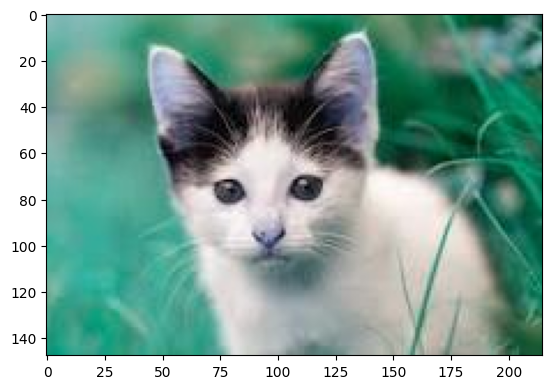

In [2]:
image = cv2.imread('cat.jpeg')
plt.imshow(image)

In [3]:
# Find the resolution of the image
image.shape

(148, 215, 3)

 ### Convolutional Layer
 - Extracts the features from Image

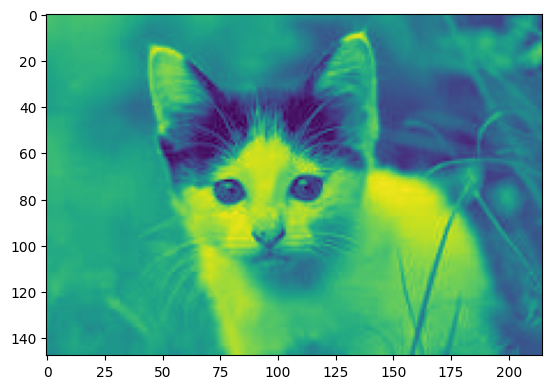

In [4]:
# Convert image to greayscale
image_grayscale = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.imshow(image_grayscale)

In [5]:
# Save the Grayscale image
cv2.imwrite('GrayScale.jpg',image_grayscale)

True

#### Resize the Image

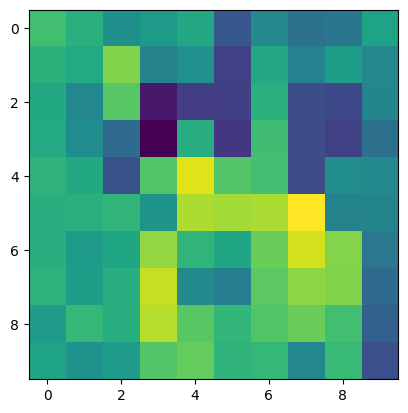

In [8]:
image_resize = cv2.resize(image_grayscale,(10,10))
plt.imshow(image_resize)

In [9]:
# Save the resized image
cv2.imwrite('image_resized.jpg',image_resize)

True

In [10]:
# get the contents of the Resized images
image_resize 

array([[173, 159, 127, 138, 151,  76, 121,  98, 103, 146],
       [160, 153, 199, 115, 129,  57, 151, 114, 141, 121],
       [152, 120, 183,  28,  54,  55, 159,  67,  63, 118],
       [153, 124,  93,  12, 156,  49, 172,  67,  57,  97],
       [162, 152,  70, 181, 233, 181, 174,  67, 125, 122],
       [158, 159, 164, 132, 215, 211, 214, 243, 115, 116],
       [157, 139, 148, 206, 163, 148, 191, 227, 200, 104],
       [161, 141, 157, 223, 122, 112, 185, 204, 199,  93],
       [140, 166, 158, 217, 183, 165, 180, 190, 173,  84],
       [146, 130, 139, 181, 188, 162, 166, 120, 168,  68]], dtype=uint8)

In [11]:
# Define the kernal
kernal = np.array([
    [1,0,-1],
    [1,0,-1],
    [1,0,-1]
])

In [12]:
kernal_size = 3
image_height,image_weidth = image_resize.shape
output_height = image_height - kernal_size + 1
output_weidth = image_weidth - kernal_size + 1

In [13]:
# define the output matrix (Feature Matrix)
feature_map = np.zeros((output_height,output_weidth))

In [14]:
feature_map

array([[0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

In [15]:
# Perform The Convulation Operations
# iterate over all rows
for i in range(output_height):
    # iterate over columns
    for j in range(output_weidth):
        window = image_resize[i:i+3,j:j+3]
        #print(window)
        # pointwise multiplication
        multiplication_result = window*kernal
        #print(multiplication_result)

        value = np.sum(multiplication_result)
        #print(f"Value : {value}")

        feature_map[i,j] = value

In [16]:
feature_map

array([[ -24.,  151.,  175.,   93.,  -97.,  -91.,  124., -106.],
       [ -10.,  242.,  136.,   -6., -143.,  -87.,  221.,  -88.],
       [ 121.,  175.,  -97.,  -64.,  -62.,   84.,  260., -136.],
       [ 146.,  110., -277., -116.,   44.,   64.,  263.,   42.],
       [  95.,  -69., -229.,  -21.,   32.,    3.,  139.,  195.],
       [   7., -122.,  -31.,   90.,  -90., -203.,   76.,  361.],
       [  -5., -200.,   -5.,  221.,  -88., -196.,  -16.,  340.],
       [  -7., -184.,  -39.,  182.,  -38.,  -75.,   -9.,  269.]])

In [17]:
feature_map.shape

(8, 8)

In [18]:
# Since the feature map cannot have any negative value apply relu 
relu_output = np.maximum(feature_map , 0)
relu_output

array([[  0., 151., 175.,  93.,   0.,   0., 124.,   0.],
       [  0., 242., 136.,   0.,   0.,   0., 221.,   0.],
       [121., 175.,   0.,   0.,   0.,  84., 260.,   0.],
       [146., 110.,   0.,   0.,  44.,  64., 263.,  42.],
       [ 95.,   0.,   0.,   0.,  32.,   3., 139., 195.],
       [  7.,   0.,   0.,  90.,   0.,   0.,  76., 361.],
       [  0.,   0.,   0., 221.,   0.,   0.,   0., 340.],
       [  0.,   0.,   0., 182.,   0.,   0.,   0., 269.]])

### Max pooling layer

In [26]:
pool_size = 2

# cal the size of the pooled matrix
pooled_height = relu_output.shape[0] // 2 # floor division
pooled_width = relu_output.shape[0]//2

# create the pooled matrix
pooled = np.zeros((pooled_height,pooled_width))


In [27]:
pooled

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [32]:
relu_output[2][4]

np.float64(0.0)

In [36]:
# Fill the pooled matrix by taking the max of the pooled_sized array
for i in range(0,relu_output.shape[0]-1,2):
    for j in range(0,relu_output.shape[1]-1,2):
        # extract the current window
        window = relu_output[i:i+2,j:j+2]
        
        # take the max value from the current window
        max_value = np.max(window)
        # update the max value to pooled matrix
        pooled[i//2,j//2] = max_value

In [37]:
pooled

array([[242., 175.,   0., 221.],
       [175.,   0.,  84., 263.],
       [ 95.,  90.,  32., 361.],
       [  0., 221.,   0., 340.]])

### Flatten the pooled matrix

In [40]:
flatten_layer = pooled.flatten()

In [41]:
flatten_layer

array([242., 175.,   0., 221., 175.,   0.,  84., 263.,  95.,  90.,  32.,
       361.,   0., 221.,   0., 340.])